# 05C — Lassa vs Ebola: Comparative Mutation Landscape Analysis

This notebook performs a **head-to-head comparison** of Lassa and Ebola mutation profiles produced by **05A** (Lassa) and **05B** (Ebola).

## What this notebook answers

1. **Which virus is more constrained?** (higher fraction of Critical sites)
2. **Where are the hotspots?** Side-by-side hotspot density comparison
3. **How do conservation and entropy profiles differ?** Distribution-level and summary statistics
4. **How do mutation risk/impact scores compare?** Which virus has more dangerous substitutions?
5. **Do the viruses separate in ESM-2 embedding space?** PCA visualization of all sequences
6. **ESM outlier comparison** — which virus has more unusual variants?
7. **Summary interpretation** — biological implications

## Inputs

- **Lassa 05A outputs:** `results/lassa_step05A/Lassa_site_scores_reference_based.csv`, `Lassa_substitution_scores_reference_based.csv`
- **Ebola 04B/05B outputs:** `results/ebola_step04A/Ebolaa_site_scores_reference_based.csv`, `Ebola_mutation_scores_reference_based.csv`, `Ebola_esm_outlier_report.csv`
- **Embeddings:** `data/embeddings/lassa_embeddings.pt`, `ebola_embeddings.pt`, metadata CSVs

## Outputs

All outputs saved to `results/comparative_05c/tables/` and `results/comparative_05c/figures/`

---

**NOTE:** Run 05A (Lassa) and 05B (Ebola) first to generate the required input tables.

## SECTION 0 — Imports, Paths & Data Loading

In [1]:
import os
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import euclidean, cosine
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)

print("\u2705 All imports successful!")

✅ All imports successful!


In [2]:
# ============================================================
# BASE DATA DIRECTORY — adjust if your repo lives elsewhere
# ============================================================
DATA_BASE = Path("/Users/user/data")

# ---------- LASSA inputs (from 05A) ----------
LASSA_SITE_CSV = DATA_BASE / "results" / "lassa_step05A" / "Lassa_site_scores_reference_based.csv"
LASSA_SUB_CSV  = DATA_BASE / "results" / "lassa_step05A" / "Lassa_substitution_scores_reference_based.csv"

# ---------- EBOLA inputs (from 04B / 05B) ----------
EBOLA_SITE_CSV = DATA_BASE / "results" / "ebola_step04A" / "Ebolaa_site_scores_reference_based.csv"
EBOLA_MUT_CSV  = DATA_BASE / "results" / "ebola_step04A" / "Ebola_mutation_scores_reference_based.csv"
EBOLA_ESM_CSV  = DATA_BASE / "results" / "ebola_step04A" / "Ebola_esm_outlier_report.csv"

# ---------- EMBEDDINGS ----------
LASSA_EMB_PT   = DATA_BASE / "embeddings" / "lassa_embeddings.pt"
LASSA_META_CSV = DATA_BASE / "embeddings" / "lassa_metadata.csv"
EBOLA_EMB_PT   = DATA_BASE / "embeddings" / "ebola_embeddings.pt"
EBOLA_META_CSV = DATA_BASE / "embeddings" / "ebola_metadata.csv"

# ---------- OUTPUTS ----------
OUT_DIR = DATA_BASE / "results" / "comparative_05c"
FIG_DIR = OUT_DIR / "figures"
TBL_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Verify all inputs exist ----------
print("=" * 70)
print("INPUT FILE VERIFICATION")
print("=" * 70)

all_inputs = {
    "Lassa site table": LASSA_SITE_CSV,
    "Lassa substitution table": LASSA_SUB_CSV,
    "Ebola site table": EBOLA_SITE_CSV,
    "Ebola mutation table": EBOLA_MUT_CSV,
    "Ebola ESM outlier CSV": EBOLA_ESM_CSV,
    "Lassa embeddings (.pt)": LASSA_EMB_PT,
    "Lassa metadata CSV": LASSA_META_CSV,
    "Ebola embeddings (.pt)": EBOLA_EMB_PT,
    "Ebola metadata CSV": EBOLA_META_CSV,
}

missing = []
for name, path in all_inputs.items():
    exists = path.exists()
    status = "\u2705" if exists else "\u274c MISSING"
    print(f"  {status}  {name}: {path}")
    if not exists:
        missing.append(name)

if missing:
    print(f"\n\u26a0\ufe0f  {len(missing)} file(s) missing. Some sections may be skipped.")
else:
    print("\n\u2705 All input files found!")

print(f"\nOutputs will be saved to: {OUT_DIR.resolve()}")

INPUT FILE VERIFICATION
  ✅  Lassa site table: /Users/user/data/results/lassa_step05A/Lassa_site_scores_reference_based.csv
  ✅  Lassa substitution table: /Users/user/data/results/lassa_step05A/Lassa_substitution_scores_reference_based.csv
  ✅  Ebola site table: /Users/user/data/results/ebola_step04A/Ebolaa_site_scores_reference_based.csv
  ✅  Ebola mutation table: /Users/user/data/results/ebola_step04A/Ebola_mutation_scores_reference_based.csv
  ✅  Ebola ESM outlier CSV: /Users/user/data/results/ebola_step04A/Ebola_esm_outlier_report.csv
  ✅  Lassa embeddings (.pt): /Users/user/data/embeddings/lassa_embeddings.pt
  ✅  Lassa metadata CSV: /Users/user/data/embeddings/lassa_metadata.csv
  ✅  Ebola embeddings (.pt): /Users/user/data/embeddings/ebola_embeddings.pt
  ✅  Ebola metadata CSV: /Users/user/data/embeddings/ebola_metadata.csv

✅ All input files found!

Outputs will be saved to: /Users/user/data/results/comparative_05c


In [3]:
# ============================================================
# LOAD SITE-LEVEL TABLES
# ============================================================
print("\n" + "=" * 70)
print("LOADING SITE-LEVEL TABLES")
print("=" * 70)

lassa_site = pd.read_csv(LASSA_SITE_CSV)
ebola_site = pd.read_csv(EBOLA_SITE_CSV)

# Tag with virus label for combined analyses
lassa_site["virus"] = "Lassa"
ebola_site["virus"] = "Ebola"

print(f"Lassa site table: {lassa_site.shape}  (ref length = {lassa_site['ref_pos'].max()})")
print(f"Ebola site table: {ebola_site.shape}  (ref length = {ebola_site['ref_pos'].max()})")
print(f"\nLassa columns: {list(lassa_site.columns)}")
print(f"Ebola columns: {list(ebola_site.columns)}")

display(lassa_site.head(3))
display(ebola_site.head(3))


LOADING SITE-LEVEL TABLES
Lassa site table: (491, 10)  (ref length = 491)
Ebola site table: (676, 10)  (ref length = 676)

Lassa columns: ['ref_pos', 'ref_aa', 'consensus_aa', 'gap_rate', 'nongap_count', 'conservation', 'entropy', 'top_aas', 'site_category', 'virus']
Ebola columns: ['ref_pos', 'ref_aa', 'consensus_aa', 'gap_rate', 'nongap_count', 'conservation', 'entropy', 'top_aas', 'site_category', 'virus']


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category,virus
0,1,M,M,0.487179,400,0.675000,1.566804,M:270;V:75;S:17;E:15;P:10,Intermediate,Lassa
1,2,G,G,0.484615,402,0.850746,1.061568,G:342;K:12;R:12;S:11;W:10,Conserved,Lassa
2,3,Q,Q,0.484615,402,0.684080,1.623073,Q:275;F:68;C:15;E:12;L:11,Intermediate,Lassa


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category,virus
0,1,M,M,0.003727,1604,1.0,0.0,M:1604,Critical,Ebola
1,2,G,G,0.004969,1602,1.0,0.0,G:1602,Critical,Ebola
2,3,V,V,0.003727,1604,1.0,0.0,V:1604,Critical,Ebola


In [4]:
# ============================================================
# LOAD SUBSTITUTION / MUTATION TABLES
# ============================================================
print("\n" + "=" * 70)
print("LOADING SUBSTITUTION / MUTATION TABLES")
print("=" * 70)

lassa_sub = pd.read_csv(LASSA_SUB_CSV)
ebola_mut = pd.read_csv(EBOLA_MUT_CSV)

# ---- Normalize column names so both tables use consistent naming ----
# Lassa uses: mut_aa, freq, impact_label
# Ebola uses: alt_aa, alt_freq_in_dataset, impact_score, impact_category

# Normalize Lassa sub table
lassa_sub_norm = lassa_sub.rename(columns={
    "mut_aa": "alt_aa",
    "freq": "alt_freq",
})
lassa_sub_norm["virus"] = "Lassa"

# Normalize Ebola mut table
ebola_mut_norm = ebola_mut.rename(columns={
    "alt_freq_in_dataset": "alt_freq",
})
ebola_mut_norm["virus"] = "Ebola"

print(f"Lassa substitution table: {lassa_sub_norm.shape}")
print(f"Ebola mutation table: {ebola_mut_norm.shape}")
print(f"\nLassa columns: {list(lassa_sub_norm.columns)}")
print(f"Ebola columns: {list(ebola_mut_norm.columns)}")

display(lassa_sub_norm.head(3))
display(ebola_mut_norm.head(3))


LOADING SUBSTITUTION / MUTATION TABLES
Lassa substitution table: (9820, 10)
Ebola mutation table: (12844, 11)

Lassa columns: ['ref_pos', 'ref_aa', 'alt_aa', 'count', 'alt_freq', 'blosum62', 'observed', 'site_category', 'impact_label', 'virus']
Ebola columns: ['ref_pos', 'ref_aa', 'alt_aa', 'alt_freq', 'blosum62', 'site_conservation', 'site_entropy', 'site_category', 'impact_score', 'impact_category', 'virus']


,ref_pos,ref_aa,alt_aa,count,alt_freq,blosum62,observed,site_category,impact_label,virus
0,1,M,V,75,0.1875,1,True,Intermediate,Intermediate,Lassa
1,1,M,R,0,0.0000,-1,False,Intermediate,Intermediate,Lassa
2,1,M,P,10,0.0250,-2,True,Intermediate,Intermediate,Lassa


,ref_pos,ref_aa,alt_aa,alt_freq,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category,virus
0,1,M,A,0.0,-1,1.0,0.0,Critical,88.749985,Critical,Ebola
1,1,M,C,0.0,-1,1.0,0.0,Critical,88.749985,Critical,Ebola
2,1,M,D,0.0,-3,1.0,0.0,Critical,96.249985,Critical,Ebola


In [5]:
# ============================================================
# LOAD EMBEDDINGS (for PCA / embedding-space comparison)
# ============================================================
print("\n" + "=" * 70)
print("LOADING EMBEDDINGS")
print("=" * 70)

lassa_emb = None
ebola_emb = None
lassa_meta = None
ebola_meta = None

if LASSA_EMB_PT.exists() and LASSA_META_CSV.exists():
    lassa_emb = torch.load(LASSA_EMB_PT, map_location="cpu").float()
    lassa_meta = pd.read_csv(LASSA_META_CSV)
    print(f"\u2705 Lassa embeddings: {lassa_emb.shape}")
    print(f"   Metadata: {lassa_meta.shape}")
else:
    print("\u274c Lassa embeddings not found. PCA section will be skipped.")

if EBOLA_EMB_PT.exists() and EBOLA_META_CSV.exists():
    ebola_emb = torch.load(EBOLA_EMB_PT, map_location="cpu").float()
    ebola_meta = pd.read_csv(EBOLA_META_CSV)
    print(f"\u2705 Ebola embeddings: {ebola_emb.shape}")
    print(f"   Metadata: {ebola_meta.shape}")
else:
    print("\u274c Ebola embeddings not found. PCA section will be skipped.")

# Load Ebola ESM outlier report (optional)
ebola_esm = None
if EBOLA_ESM_CSV.exists():
    ebola_esm = pd.read_csv(EBOLA_ESM_CSV)
    print(f"\u2705 Ebola ESM outlier report: {ebola_esm.shape}")

print("\n\u2705 Data loading complete!")


LOADING EMBEDDINGS
✅ Lassa embeddings: torch.Size([780, 1280])
   Metadata: (780, 5)
✅ Ebola embeddings: torch.Size([1610, 1280])
   Metadata: (1610, 5)
✅ Ebola ESM outlier report: (1610, 8)

✅ Data loading complete!


---

## SECTION 1 — Site Category Comparison

**Question:** Which virus is more constrained? How do the distributions of Critical / Conserved / Hotspot / Intermediate / MostlyGap sites compare?

This is the most fundamental comparison: it tells us the overall evolutionary "freedom" of each virus protein.

In [6]:
# ============================================================
# 1.1 — Compute site category fractions for each virus
# ============================================================
ALL_CATS = ["Critical", "Conserved", "Hotspot", "Intermediate", "MostlyGap"]

def site_category_summary(site_df, virus_name):
    counts = site_df["site_category"].value_counts()
    total = counts.sum()
    rows = []
    for cat in ALL_CATS:
        c = counts.get(cat, 0)
        rows.append({"virus": virus_name, "site_category": cat, "count": int(c), "fraction": c / total})
    return pd.DataFrame(rows)

lassa_cat = site_category_summary(lassa_site, "Lassa")
ebola_cat = site_category_summary(ebola_site, "Ebola")
cat_compare = pd.concat([lassa_cat, ebola_cat], ignore_index=True)

print("Site Category Comparison (fractions):")
pivot = cat_compare.pivot(index="site_category", columns="virus", values="fraction").reindex(ALL_CATS)
pivot["difference (Ebola - Lassa)"] = pivot["Ebola"] - pivot["Lassa"]
display(pivot)

cat_compare.to_csv(TBL_DIR / "site_category_comparison.csv", index=False)
print("\u2705 Saved: site_category_comparison.csv")

Site Category Comparison (fractions):


virus,Ebola,Lassa,difference (Ebola - Lassa)
site_category,,,
Critical,0.989645,0.004073,0.985572
Conserved,0.008876,0.069246,-0.060371
Hotspot,0.000000,0.348269,-0.348269
Intermediate,0.000000,0.407332,-0.407332
MostlyGap,0.001479,0.171079,-0.169600


✅ Saved: site_category_comparison.csv


✅ Saved: 01_site_category_comparison.png


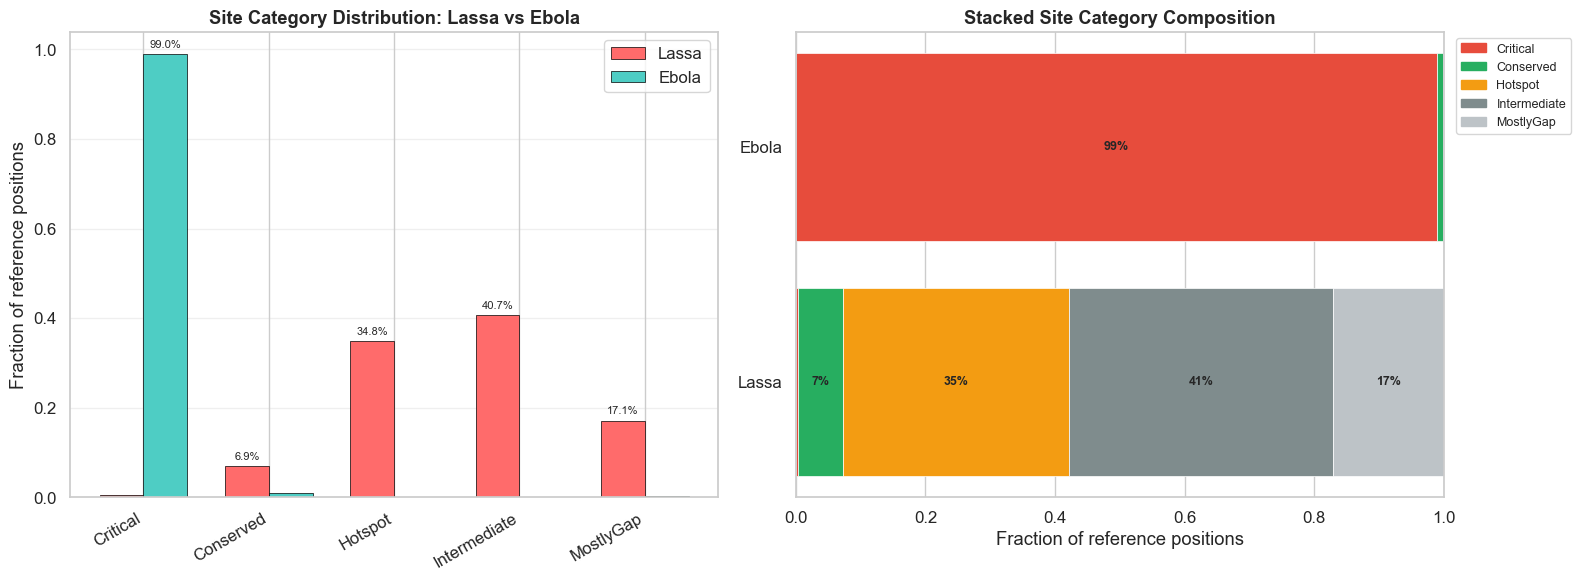

In [7]:
# ============================================================
# 1.2 — Side-by-side bar chart: site category fractions
# ============================================================
cat_colors = {
    "Critical": "#e74c3c",
    "Conserved": "#27ae60",
    "Hotspot": "#f39c12",
    "Intermediate": "#7f8c8d",
    "MostlyGap": "#bdc3c7",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart (grouped) ---
ax = axes[0]
x = np.arange(len(ALL_CATS))
width = 0.35
lassa_vals = [pivot.loc[c, "Lassa"] for c in ALL_CATS]
ebola_vals = [pivot.loc[c, "Ebola"] for c in ALL_CATS]

bars1 = ax.bar(x - width/2, lassa_vals, width, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, ebola_vals, width, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(ALL_CATS, rotation=30, ha="right")
ax.set_ylabel("Fraction of reference positions")
ax.set_title("Site Category Distribution: Lassa vs Ebola", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value labels
for bar in bars1:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.1%}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.1%}", ha="center", va="bottom", fontsize=8)

# --- Stacked horizontal bar chart ---
ax = axes[1]
for i, virus in enumerate(["Lassa", "Ebola"]):
    left = 0
    for cat in ALL_CATS:
        val = pivot.loc[cat, virus]
        ax.barh(virus, val, left=left, color=cat_colors[cat], edgecolor="white", linewidth=0.5)
        if val > 0.05:
            ax.text(left + val/2, i, f"{val:.0%}", ha="center", va="center", fontsize=9, fontweight="bold")
        left += val

handles = [mpatches.Patch(color=cat_colors[c], label=c) for c in ALL_CATS]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xlabel("Fraction of reference positions")
ax.set_title("Stacked Site Category Composition", fontweight="bold")
ax.set_xlim(0, 1)

plt.tight_layout()
fig_path = FIG_DIR / "01_site_category_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

In [8]:
# ============================================================
# 1.3 — Interpretation: which virus is more constrained?
# ============================================================
lassa_critical_frac = pivot.loc["Critical", "Lassa"]
ebola_critical_frac = pivot.loc["Critical", "Ebola"]
lassa_hotspot_frac = pivot.loc["Hotspot", "Lassa"]
ebola_hotspot_frac = pivot.loc["Hotspot", "Ebola"]

print("=" * 70)
print("SITE CATEGORY INTERPRETATION")
print("=" * 70)
print(f"\nLassa:  {lassa_critical_frac:.1%} Critical, {lassa_hotspot_frac:.1%} Hotspot (ref length = {lassa_site['ref_pos'].max()})")
print(f"Ebola:  {ebola_critical_frac:.1%} Critical, {ebola_hotspot_frac:.1%} Hotspot (ref length = {ebola_site['ref_pos'].max()})")

if ebola_critical_frac > lassa_critical_frac:
    print(f"\n\u27a1\ufe0f  Ebola is MORE constrained ({ebola_critical_frac:.1%} vs {lassa_critical_frac:.1%} Critical sites).")
    print("   This suggests Ebola protein is under stronger purifying selection.")
else:
    print(f"\n\u27a1\ufe0f  Lassa is MORE constrained ({lassa_critical_frac:.1%} vs {ebola_critical_frac:.1%} Critical sites).")
    print("   This suggests Lassa protein is under stronger purifying selection.")

if lassa_hotspot_frac > ebola_hotspot_frac:
    print(f"\n\u27a1\ufe0f  Lassa has MORE hotspots ({lassa_hotspot_frac:.1%} vs {ebola_hotspot_frac:.1%}).")
    print("   This indicates greater mutational freedom / adaptive variation in Lassa.")
else:
    print(f"\n\u27a1\ufe0f  Ebola has MORE hotspots ({ebola_hotspot_frac:.1%} vs {lassa_hotspot_frac:.1%}).")
    print("   This indicates greater mutational freedom / adaptive variation in Ebola.")

SITE CATEGORY INTERPRETATION

Lassa:  0.4% Critical, 34.8% Hotspot (ref length = 491)
Ebola:  99.0% Critical, 0.0% Hotspot (ref length = 676)

➡️  Ebola is MORE constrained (99.0% vs 0.4% Critical sites).
   This suggests Ebola protein is under stronger purifying selection.

➡️  Lassa has MORE hotspots (34.8% vs 0.0%).
   This indicates greater mutational freedom / adaptive variation in Lassa.


---

## SECTION 2 — Conservation & Entropy Comparison

**Question:** How do the distributions of per-site conservation and entropy compare between Lassa and Ebola?

- Higher conservation = more residues are identical across sequences
- Higher entropy = more amino acid diversity at that position

In [9]:
# ============================================================
# 2.1 — Summary statistics: conservation & entropy
# ============================================================
print("=" * 70)
print("CONSERVATION & ENTROPY SUMMARY STATISTICS")
print("=" * 70)

stats_rows = []
for virus, site_df in [("Lassa", lassa_site), ("Ebola", ebola_site)]:
    for metric in ["conservation", "entropy"]:
        vals = site_df[metric].dropna()
        stats_rows.append({
            "virus": virus,
            "metric": metric,
            "mean": vals.mean(),
            "median": vals.median(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
            "q25": vals.quantile(0.25),
            "q75": vals.quantile(0.75),
        })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
stats_df.to_csv(TBL_DIR / "conservation_entropy_summary_stats.csv", index=False)
print("\u2705 Saved: conservation_entropy_summary_stats.csv")

CONSERVATION & ENTROPY SUMMARY STATISTICS


,virus,metric,mean,median,std,min,max,q25,q75
0,Lassa,conservation,0.616320,0.576671,0.203912,0.267133,1.000000,0.433183,0.770911
1,Lassa,entropy,1.507839,1.620704,0.705148,0.000000,2.973391,1.168085,2.032504
2,Ebola,conservation,0.997476,1.000000,0.038980,0.000000,1.000000,0.999377,1.000000
3,Ebola,entropy,0.007796,0.000000,0.037230,0.000000,0.511697,0.000000,0.007533


✅ Saved: conservation_entropy_summary_stats.csv


✅ Saved: 02_conservation_entropy_distributions.png


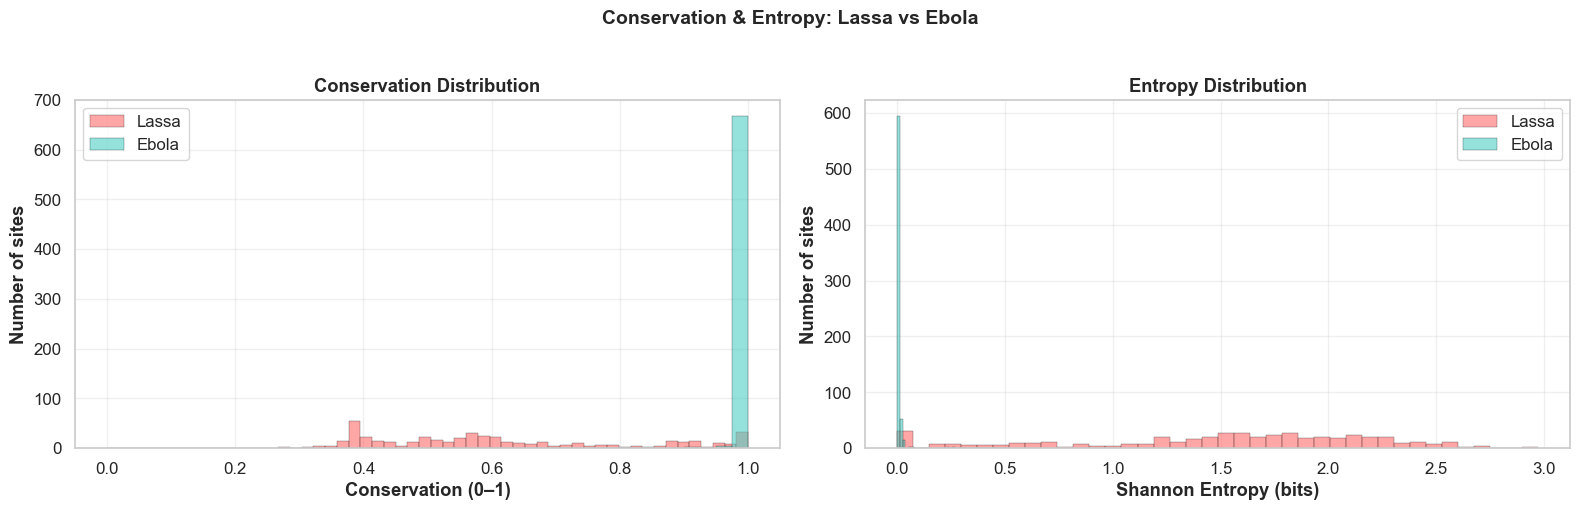

In [10]:
# ============================================================
# 2.2 — Overlaid distribution plots: conservation & entropy
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Conservation distribution
ax = axes[0]
ax.hist(lassa_site["conservation"].dropna(), bins=40, alpha=0.6, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.3)
ax.hist(ebola_site["conservation"].dropna(), bins=40, alpha=0.6, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Conservation (0\u20131)", fontweight="bold")
ax.set_ylabel("Number of sites", fontweight="bold")
ax.set_title("Conservation Distribution", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# Entropy distribution
ax = axes[1]
ax.hist(lassa_site["entropy"].dropna(), bins=40, alpha=0.6, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.3)
ax.hist(ebola_site["entropy"].dropna(), bins=40, alpha=0.6, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Shannon Entropy (bits)", fontweight="bold")
ax.set_ylabel("Number of sites", fontweight="bold")
ax.set_title("Entropy Distribution", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Conservation & Entropy: Lassa vs Ebola", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIG_DIR / "02_conservation_entropy_distributions.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

✅ Saved: 03_conservation_entropy_violins.png


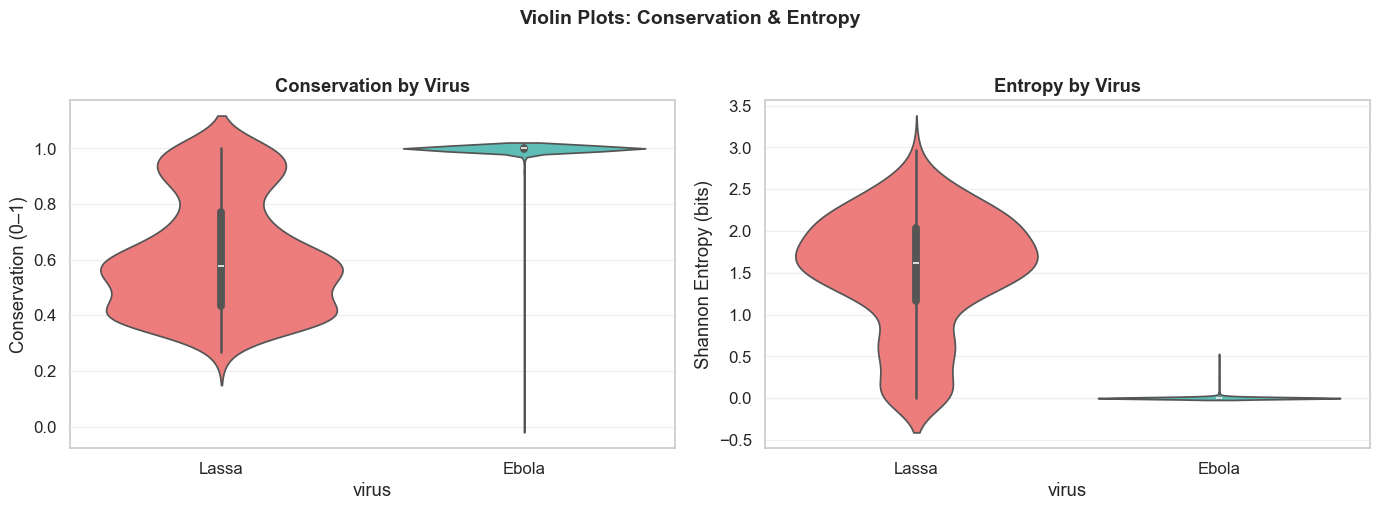

In [11]:
# ============================================================
# 2.3 — Violin + Box plots for conservation & entropy
# ============================================================
combined_site = pd.concat([
    lassa_site[["conservation", "entropy", "virus"]],
    ebola_site[["conservation", "entropy", "virus"]]
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.violinplot(data=combined_site, x="virus", y="conservation", ax=ax,
               palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
ax.set_title("Conservation by Virus", fontweight="bold")
ax.set_ylabel("Conservation (0\u20131)")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
sns.violinplot(data=combined_site, x="virus", y="entropy", ax=ax,
               palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
ax.set_title("Entropy by Virus", fontweight="bold")
ax.set_ylabel("Shannon Entropy (bits)")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Violin Plots: Conservation & Entropy", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIG_DIR / "03_conservation_entropy_violins.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

In [12]:
# ============================================================
# 2.4 — Statistical test: are the distributions different?
# ============================================================
print("=" * 70)
print("STATISTICAL TESTS (Mann-Whitney U)")
print("=" * 70)

for metric in ["conservation", "entropy"]:
    lassa_vals = lassa_site[metric].dropna().values
    ebola_vals = ebola_site[metric].dropna().values
    stat, pval = stats.mannwhitneyu(lassa_vals, ebola_vals, alternative="two-sided")
    print(f"\n{metric.upper()}:")
    print(f"  Lassa mean = {lassa_vals.mean():.4f}, Ebola mean = {ebola_vals.mean():.4f}")
    print(f"  Mann-Whitney U = {stat:.1f}, p-value = {pval:.2e}")
    if pval < 0.001:
        print(f"  \u27a1\ufe0f  Highly significant difference (p < 0.001)")
    elif pval < 0.05:
        print(f"  \u27a1\ufe0f  Significant difference (p < 0.05)")
    else:
        print(f"  \u27a1\ufe0f  No significant difference (p >= 0.05)")

STATISTICAL TESTS (Mann-Whitney U)

CONSERVATION:
  Lassa mean = 0.6163, Ebola mean = 0.9975
  Mann-Whitney U = 9839.5, p-value = 5.05e-181
  ➡️  Highly significant difference (p < 0.001)

ENTROPY:
  Lassa mean = 1.5078, Ebola mean = 0.0078
  Mann-Whitney U = 322583.0, p-value = 2.78e-182
  ➡️  Highly significant difference (p < 0.001)


---

## SECTION 3 — Mutation Impact / Risk Score Comparison

**Question:** Which virus has more high-impact (dangerous) substitutions? How do the impact score distributions compare?

We compare:
- Distribution of impact scores (Ebola has `impact_score` 0\u2013100; Lassa uses categorical `impact_label`)
- BLOSUM62 score distributions for observed vs unobserved substitutions
- Impact category fractions

In [13]:
# ============================================================
# 3.1 — Impact category comparison
# ============================================================
print("=" * 70)
print("IMPACT / RISK CATEGORY COMPARISON")
print("=" * 70)

# Lassa uses impact_label; Ebola uses impact_category
print("\n--- Lassa impact_label distribution ---")
if "impact_label" in lassa_sub_norm.columns:
    lassa_impact_counts = lassa_sub_norm["impact_label"].value_counts()
    lassa_impact_frac = lassa_impact_counts / lassa_impact_counts.sum()
    display(pd.DataFrame({"count": lassa_impact_counts, "fraction": lassa_impact_frac}))
else:
    print("No impact_label column in Lassa substitution table.")

print("\n--- Ebola impact_category distribution ---")
if "impact_category" in ebola_mut_norm.columns:
    ebola_impact_counts = ebola_mut_norm["impact_category"].value_counts()
    ebola_impact_frac = ebola_impact_counts / ebola_impact_counts.sum()
    display(pd.DataFrame({"count": ebola_impact_counts, "fraction": ebola_impact_frac}))
else:
    print("No impact_category column in Ebola mutation table.")

IMPACT / RISK CATEGORY COMPARISON

--- Lassa impact_label distribution ---


,count,fraction
impact_label,,
Intermediate,7225,0.735743
HotspotNegative,2373,0.241650
LowImpact,213,0.021690
HighImpact,9,0.000916



--- Ebola impact_category distribution ---


,count,fraction
impact_category,,
Critical,12270,0.955310
Dangerous,555,0.043211
Neutral,15,0.001168
Moderate,4,0.000311


✅ Saved: 04_blosum62_distributions.png


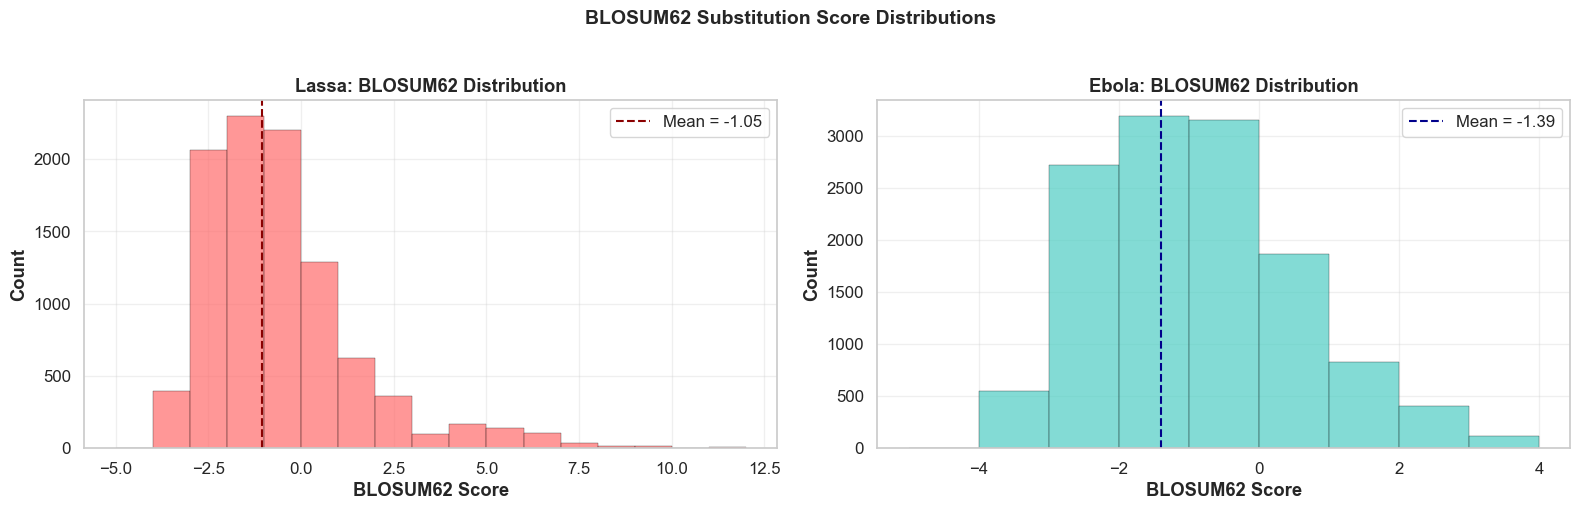

In [14]:
# ============================================================
# 3.2 — BLOSUM62 score comparison (both tables have this)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Lassa BLOSUM62 distribution
ax = axes[0]
lassa_blosum = lassa_sub_norm["blosum62"].dropna()
ax.hist(lassa_blosum, bins=range(int(lassa_blosum.min())-1, int(lassa_blosum.max())+2),
        alpha=0.7, color="#FF6B6B", edgecolor="black", linewidth=0.3)
ax.axvline(lassa_blosum.mean(), color="darkred", linestyle="--", label=f"Mean = {lassa_blosum.mean():.2f}")
ax.set_xlabel("BLOSUM62 Score", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Lassa: BLOSUM62 Distribution", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# Ebola BLOSUM62 distribution
ax = axes[1]
ebola_blosum = ebola_mut_norm["blosum62"].dropna()
ax.hist(ebola_blosum, bins=range(int(ebola_blosum.min())-1, int(ebola_blosum.max())+2),
        alpha=0.7, color="#4ECDC4", edgecolor="black", linewidth=0.3)
ax.axvline(ebola_blosum.mean(), color="darkblue", linestyle="--", label=f"Mean = {ebola_blosum.mean():.2f}")
ax.set_xlabel("BLOSUM62 Score", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Ebola: BLOSUM62 Distribution", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("BLOSUM62 Substitution Score Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIG_DIR / "04_blosum62_distributions.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

✅ Saved: 05_ebola_impact_score_distribution.png


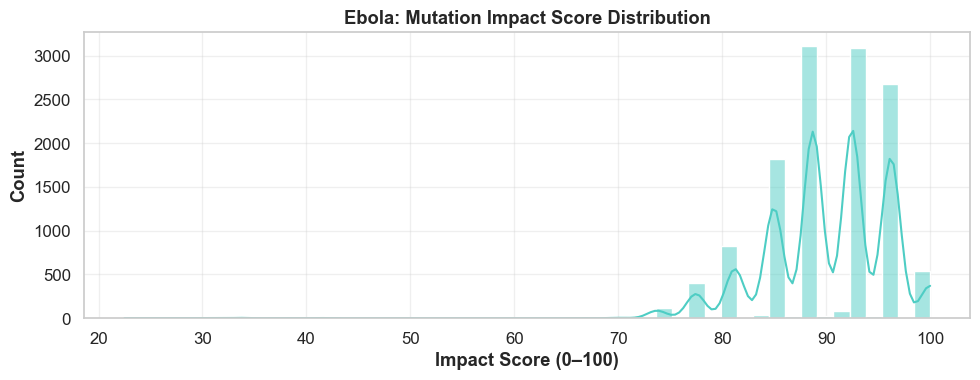

In [15]:
# ============================================================
# 3.3 — Ebola impact_score distribution (Ebola has numeric scores)
# ============================================================
if "impact_score" in ebola_mut_norm.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(ebola_mut_norm["impact_score"].dropna(), bins=50, kde=True, color="#4ECDC4", ax=ax)
    ax.set_xlabel("Impact Score (0\u2013100)", fontweight="bold")
    ax.set_ylabel("Count", fontweight="bold")
    ax.set_title("Ebola: Mutation Impact Score Distribution", fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = FIG_DIR / "05_ebola_impact_score_distribution.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\u2705 Saved: {fig_path.name}")
    plt.show()
else:
    print("No impact_score column in Ebola table; skipping.")

In [17]:
# ============================================================
# 3.4 — Observed vs unobserved substitutions comparison
# ============================================================
print("=" * 70)
print("OBSERVED vs UNOBSERVED SUBSTITUTIONS")
print("=" * 70)

# Lassa: uses 'observed' column (bool) and 'alt_freq'
if "observed" in lassa_sub_norm.columns:
    lassa_obs = lassa_sub_norm["observed"].value_counts()
    lassa_obs_frac = lassa_obs / lassa_obs.sum()
    print(f"\nLassa: {lassa_obs.get(True, 0):,} observed, {lassa_obs.get(False, 0):,} unobserved")
    print(f"  Observed fraction: {lassa_obs_frac.get(True, 0):.1%}")

# Ebola: uses 'alt_freq' > 0
if "alt_freq" in ebola_mut_norm.columns:
    ebola_obs_count = (ebola_mut_norm["alt_freq"] > 0).sum()
    ebola_unobs_count = (ebola_mut_norm["alt_freq"] == 0).sum()
    ebola_total = len(ebola_mut_norm)
    print(f"\nEbola: {ebola_obs_count:,} observed, {ebola_unobs_count:,} unobserved")
    print(f"  Observed fraction: {ebola_obs_count / ebola_total:.1%}")

# Combined comparison table
obs_compare = pd.DataFrame([
    {"virus": "Lassa", "observed": lassa_obs.get(True, 0), "unobserved": lassa_obs.get(False, 0),
     "obs_fraction": lassa_obs_frac.get(True, 0)},
    {"virus": "Ebola", "observed": ebola_obs_count, "unobserved": ebola_unobs_count,
     "obs_fraction": ebola_obs_count / ebola_total},
])
display(obs_compare)
obs_compare.to_csv(TBL_DIR / "observed_substitution_comparison.csv", index=False)
print("\u2705 Saved: observed_substitution_comparison.csv")

OBSERVED vs UNOBSERVED SUBSTITUTIONS

Lassa: 4,128 observed, 5,692 unobserved
  Observed fraction: 42.0%

Ebola: 255 observed, 12,589 unobserved
  Observed fraction: 2.0%


,virus,observed,unobserved,obs_fraction
0,Lassa,4128,5692,0.420367
1,Ebola,255,12589,0.019854


✅ Saved: observed_substitution_comparison.csv


---

## SECTION 4 — ESM-2 Embedding Space: PCA Visualization

**Question:** Do Lassa and Ebola sequences separate cleanly in ESM-2 embedding space?

We combine Lassa + Ebola embeddings, apply PCA, and visualize the 2D landscape with:
- Scatter plot colored by virus
- Centroids and inter-centroid distance
- Separation ratio (between-cluster / within-cluster distance)

In [18]:
# ============================================================
# 4.1 — Combine embeddings + PCA
# ============================================================
if lassa_emb is not None and ebola_emb is not None:
    print("=" * 70)
    print("EMBEDDING-SPACE PCA ANALYSIS")
    print("=" * 70)

    all_emb = torch.cat([lassa_emb, ebola_emb], dim=0).numpy()
    labels = ["Lassa"] * len(lassa_emb) + ["Ebola"] * len(ebola_emb)
    print(f"\nCombined embeddings: {all_emb.shape}")
    print(f"  Lassa: {len(lassa_emb)}")
    print(f"  Ebola: {len(ebola_emb)}")

    # PCA
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(all_emb)

    print(f"\nPCA explained variance:")
    print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

    # Split back
    lassa_2d = emb_2d[:len(lassa_emb)]
    ebola_2d = emb_2d[len(lassa_emb):]

    # Centroids in 2D
    lassa_cent = lassa_2d.mean(axis=0)
    ebola_cent = ebola_2d.mean(axis=0)

    # Centroid distance in full embedding space
    lassa_centroid_full = lassa_emb.mean(dim=0).numpy()
    ebola_centroid_full = ebola_emb.mean(dim=0).numpy()
    euclid_dist = euclidean(lassa_centroid_full, ebola_centroid_full)
    cos_dist = cosine(lassa_centroid_full, ebola_centroid_full)

    # Within-cluster distances (sampled)
    lassa_dists = [euclidean(lassa_emb[i].numpy(), lassa_centroid_full)
                   for i in range(0, len(lassa_emb), max(1, len(lassa_emb)//100))]
    ebola_dists = [euclidean(ebola_emb[i].numpy(), ebola_centroid_full)
                   for i in range(0, len(ebola_emb), max(1, len(ebola_emb)//100))]

    sep_ratio = euclid_dist / (np.mean(lassa_dists) + np.mean(ebola_dists))

    print(f"\nCentroid distances (1280D):")
    print(f"  Euclidean: {euclid_dist:.4f}")
    print(f"  Cosine:    {cos_dist:.6f}")
    print(f"\nWithin-cluster mean distances:")
    print(f"  Lassa: {np.mean(lassa_dists):.4f} \u00b1 {np.std(lassa_dists):.4f}")
    print(f"  Ebola: {np.mean(ebola_dists):.4f} \u00b1 {np.std(ebola_dists):.4f}")
    print(f"\nSeparation ratio: {sep_ratio:.4f}")
    if sep_ratio > 2:
        print("\u2705 EXCELLENT separation")
    elif sep_ratio > 1:
        print("\u2705 GOOD separation")
    else:
        print("\u26a0\ufe0f  POOR separation (clusters overlap)")
else:
    print("\u26a0\ufe0f  Embeddings not available. Skipping PCA section.")

EMBEDDING-SPACE PCA ANALYSIS

Combined embeddings: (2390, 1280)
  Lassa: 780
  Ebola: 1610

PCA explained variance:
  PC1: 43.9%
  PC2: 29.1%
  Total: 73.0%

Centroid distances (1280D):
  Euclidean: 1.5857
  Cosine:    0.013205

Within-cluster mean distances:
  Lassa: 1.4792 ± 0.1930
  Ebola: 0.1160 ± 0.0609

Separation ratio: 0.9940
⚠️  POOR separation (clusters overlap)


✅ Saved: 06_pca_lassa_vs_ebola.png


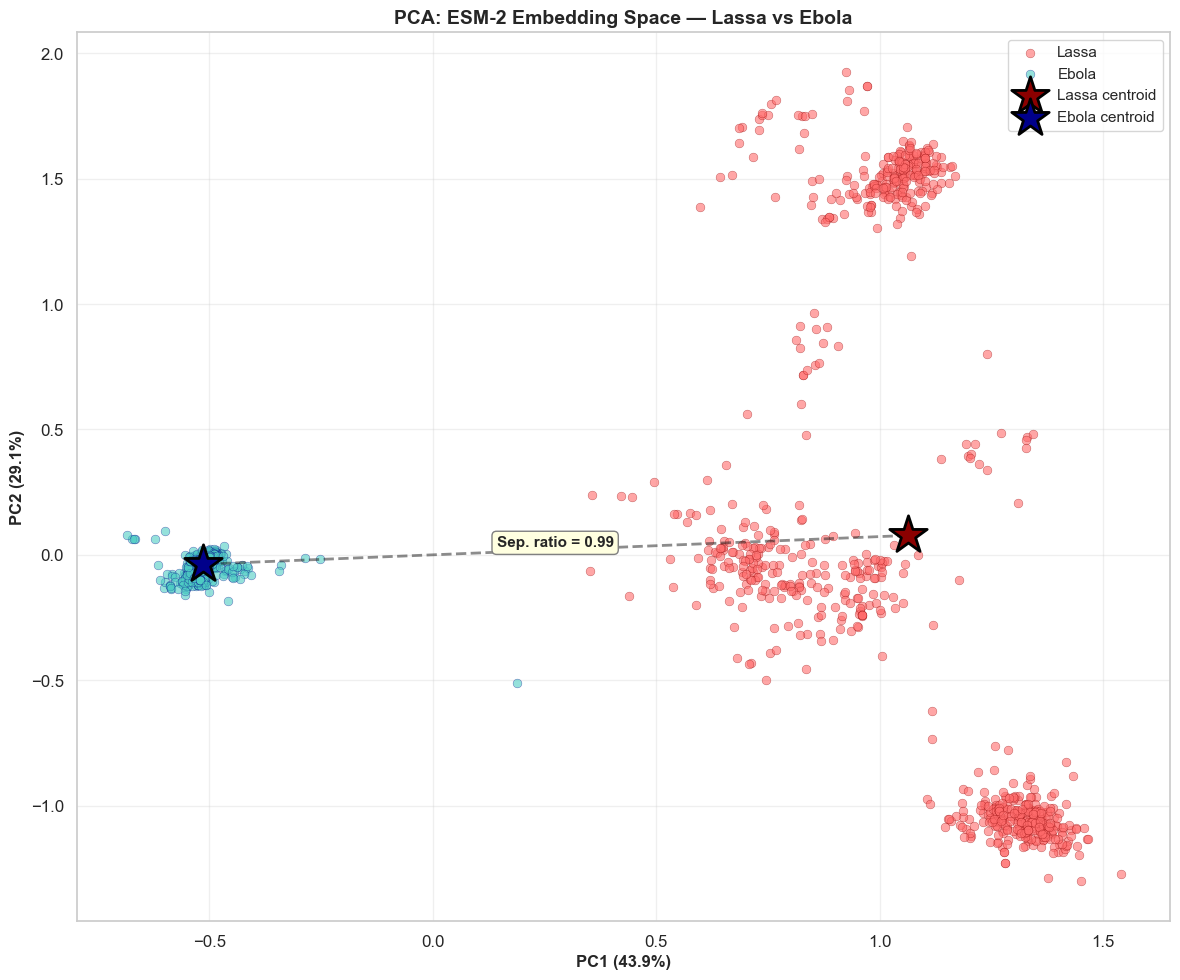

In [19]:
# ============================================================
# 4.2 — PCA scatter plot
# ============================================================
if lassa_emb is not None and ebola_emb is not None:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.scatter(lassa_2d[:, 0], lassa_2d[:, 1], c="#FF6B6B", label="Lassa",
               alpha=0.6, s=40, edgecolors="darkred", linewidth=0.3)
    ax.scatter(ebola_2d[:, 0], ebola_2d[:, 1], c="#4ECDC4", label="Ebola",
               alpha=0.6, s=40, edgecolors="darkblue", linewidth=0.3)

    # Centroids
    ax.scatter(*lassa_cent, c="darkred", marker="*", s=800, edgecolor="black",
               linewidth=2, label="Lassa centroid", zorder=5)
    ax.scatter(*ebola_cent, c="darkblue", marker="*", s=800, edgecolor="black",
               linewidth=2, label="Ebola centroid", zorder=5)

    # Line between centroids
    ax.plot([lassa_cent[0], ebola_cent[0]], [lassa_cent[1], ebola_cent[1]],
            "k--", linewidth=2, alpha=0.5)

    # Annotation
    mid = (lassa_cent + ebola_cent) / 2
    ax.annotate(f"Sep. ratio = {sep_ratio:.2f}", xy=mid, fontsize=11,
                ha="center", va="bottom", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontweight="bold", fontsize=12)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontweight="bold", fontsize=12)
    ax.set_title("PCA: ESM-2 Embedding Space — Lassa vs Ebola", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11, loc="best")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = FIG_DIR / "06_pca_lassa_vs_ebola.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\u2705 Saved: {fig_path.name}")
    plt.show()
else:
    print("Skipping PCA plot (no embeddings).")

✅ Saved: 07_pca_kde_contours.png


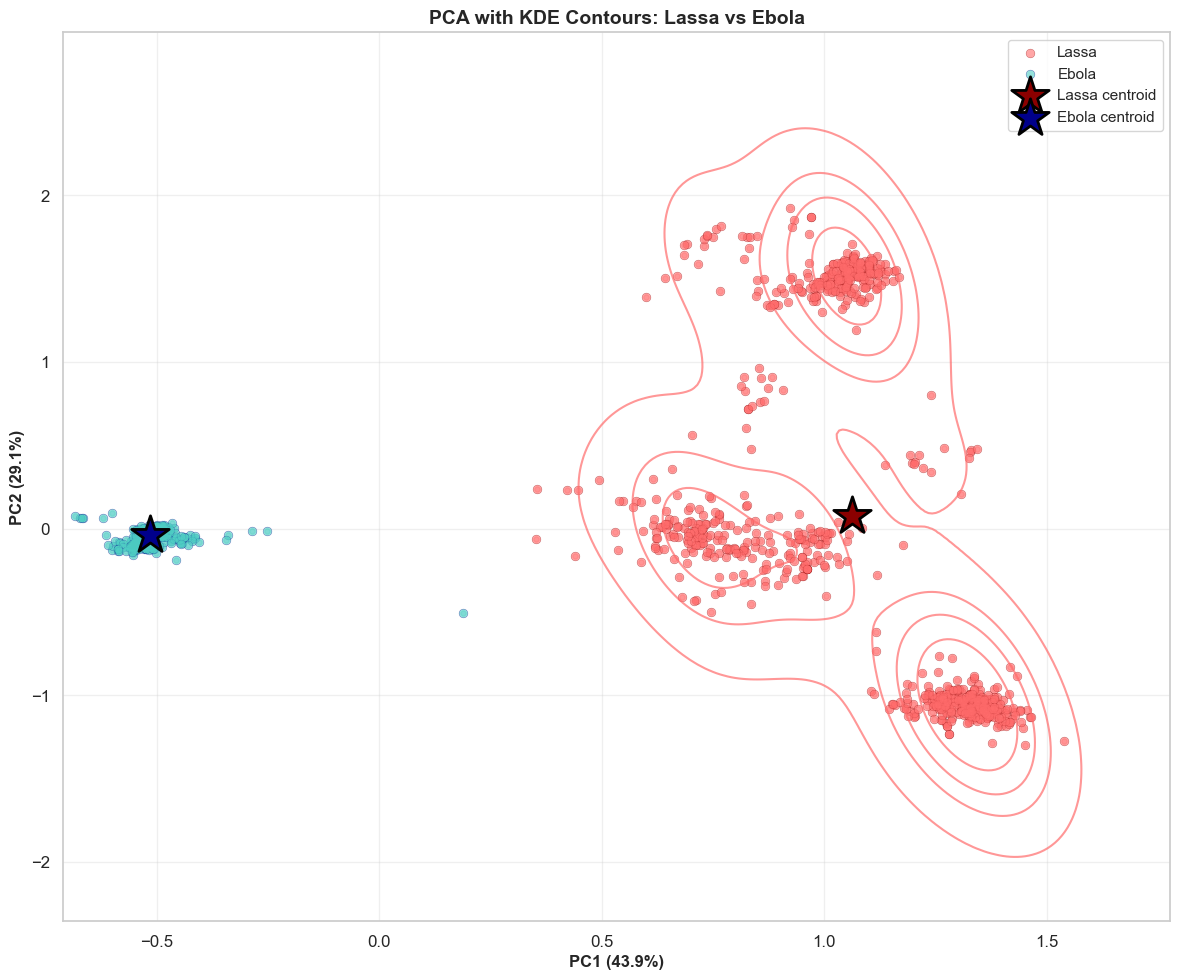

In [22]:
# ============================================================
# 4.3 — PCA with density contours (KDE)
# ============================================================
if lassa_emb is not None and ebola_emb is not None:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.scatter(lassa_2d[:, 0], lassa_2d[:, 1], c="#FF6B6B", label="Lassa",
               alpha=0.6, s=40, edgecolors="darkred", linewidth=0.3)
    ax.scatter(ebola_2d[:, 0], ebola_2d[:, 1], c="#4ECDC4", label="Ebola",
               alpha=0.6, s=40, edgecolors="darkblue", linewidth=0.3)
    # KDE contours
    sns.kdeplot(x=lassa_2d[:, 0], y=lassa_2d[:, 1], ax=ax, color="#FF6B6B",
                levels=5, linewidths=1.5, alpha=0.7, label="Lassa density")
    sns.kdeplot(x=ebola_2d[:, 0], y=ebola_2d[:, 1], ax=ax, color="#4ECDC4",
                levels=5, linewidths=1.5, alpha=0.7, label="Ebola density")

    # Scatter (smaller, more transparent)
    ax.scatter(lassa_2d[:, 0], lassa_2d[:, 1], c="#FF6B6B", alpha=0.3, s=15)
    ax.scatter(ebola_2d[:, 0], ebola_2d[:, 1], c="#4ECDC4", alpha=0.3, s=15)

    # Centroids
    ax.scatter(*lassa_cent, c="darkred", marker="*", s=800, edgecolor="black",
               linewidth=2, label="Lassa centroid", zorder=5)
    ax.scatter(*ebola_cent, c="darkblue", marker="*", s=800, edgecolor="black",
               linewidth=2, label="Ebola centroid", zorder=5)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontweight="bold", fontsize=12)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontweight="bold", fontsize=12)
    ax.set_title("PCA with KDE Contours: Lassa vs Ebola", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = FIG_DIR / "07_pca_kde_contours.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\u2705 Saved: {fig_path.name}")
    plt.show()
else:
    print("Skipping KDE plot (no embeddings).")

✅ Saved: 08_embedding_norm_comparison.png


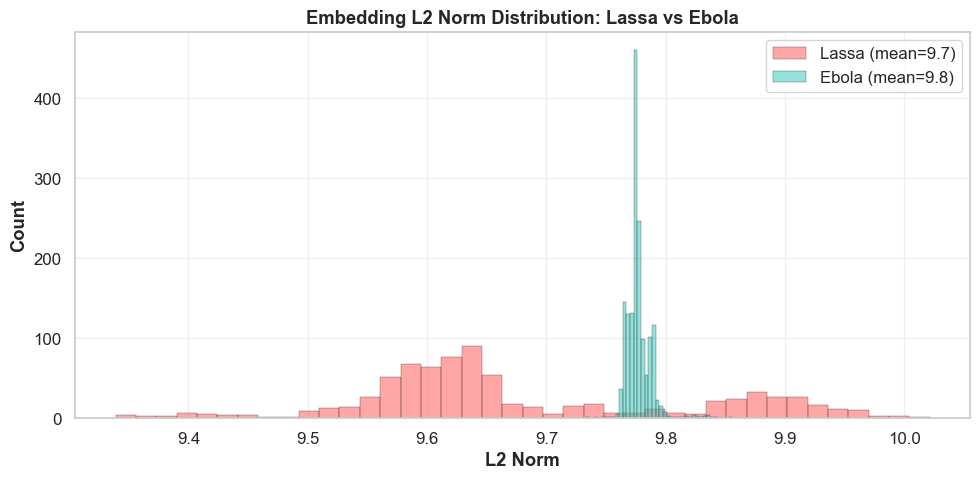

,virus,n_sequences,emb_dim,norm_mean,norm_std,centroid_euclidean_dist,centroid_cosine_dist,separation_ratio
0,Lassa,780,1280,9.678147,0.138214,1.585661,0.013205,0.994039
1,Ebola,1610,1280,9.777345,0.010220,1.585661,0.013205,0.994039


✅ Saved: embedding_comparison_stats.csv


In [23]:
# ============================================================
# 4.4 — Embedding norm comparison
# ============================================================
if lassa_emb is not None and ebola_emb is not None:
    lassa_norms = torch.linalg.norm(lassa_emb, dim=1).numpy()
    ebola_norms = torch.linalg.norm(ebola_emb, dim=1).numpy()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(lassa_norms, bins=40, alpha=0.6, label=f"Lassa (mean={lassa_norms.mean():.1f})",
            color="#FF6B6B", edgecolor="black", linewidth=0.3)
    ax.hist(ebola_norms, bins=40, alpha=0.6, label=f"Ebola (mean={ebola_norms.mean():.1f})",
            color="#4ECDC4", edgecolor="black", linewidth=0.3)
    ax.set_xlabel("L2 Norm", fontweight="bold")
    ax.set_ylabel("Count", fontweight="bold")
    ax.set_title("Embedding L2 Norm Distribution: Lassa vs Ebola", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = FIG_DIR / "08_embedding_norm_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\u2705 Saved: {fig_path.name}")
    plt.show()

    # Save embedding comparison stats
    emb_stats = pd.DataFrame([
        {"virus": "Lassa", "n_sequences": len(lassa_emb), "emb_dim": lassa_emb.shape[1],
         "norm_mean": lassa_norms.mean(), "norm_std": lassa_norms.std()},
        {"virus": "Ebola", "n_sequences": len(ebola_emb), "emb_dim": ebola_emb.shape[1],
         "norm_mean": ebola_norms.mean(), "norm_std": ebola_norms.std()},
    ])
    emb_stats["centroid_euclidean_dist"] = euclid_dist
    emb_stats["centroid_cosine_dist"] = cos_dist
    emb_stats["separation_ratio"] = sep_ratio
    emb_stats.to_csv(TBL_DIR / "embedding_comparison_stats.csv", index=False)
    display(emb_stats)
    print("\u2705 Saved: embedding_comparison_stats.csv")
else:
    print("Skipping embedding norm comparison (no embeddings).")

---

## SECTION 5 — ESM Outlier Comparison

**Question:** Which virus has more unusual/adaptive sequences (ESM outliers)?

We compute cosine-distance-to-centroid outlier scores for both viruses and compare distributions.

In [24]:
# ============================================================
# 5.1 — Compute outlier scores from embeddings (both viruses)
# ============================================================
def compute_outlier_scores(emb_tensor, eps=1e-12):
    """Compute cosine-distance-based outlier scores (0-100) from embeddings."""
    X = emb_tensor.float()
    Xn = X / (torch.linalg.norm(X, dim=1, keepdim=True) + eps)
    centroid = Xn.mean(dim=0)
    sim = Xn @ centroid
    dist = 1.0 - sim

    # Robust z-score
    med = dist.median()
    mad = (dist - med).abs().median()
    z = (dist - med) / (1.4826 * mad + eps)

    # Map to 0-100
    zc = torch.clamp(z, -6, 6)
    score = (zc + 6) * (100.0 / 12.0)
    return dist.numpy(), score.numpy()

if lassa_emb is not None and ebola_emb is not None:
    print("=" * 70)
    print("ESM OUTLIER ANALYSIS")
    print("=" * 70)

    lassa_cos_dist, lassa_outlier_score = compute_outlier_scores(lassa_emb)
    ebola_cos_dist, ebola_outlier_score = compute_outlier_scores(ebola_emb)

    print(f"\nLassa outlier scores: mean={lassa_outlier_score.mean():.1f}, std={lassa_outlier_score.std():.1f}")
    print(f"Ebola outlier scores: mean={ebola_outlier_score.mean():.1f}, std={ebola_outlier_score.std():.1f}")
else:
    print("\u26a0\ufe0f  Embeddings not loaded. Skipping outlier computation.")

ESM OUTLIER ANALYSIS

Lassa outlier scores: mean=51.7, std=9.4
Ebola outlier scores: mean=56.9, std=16.6


✅ Saved: 09_outlier_score_comparison.png


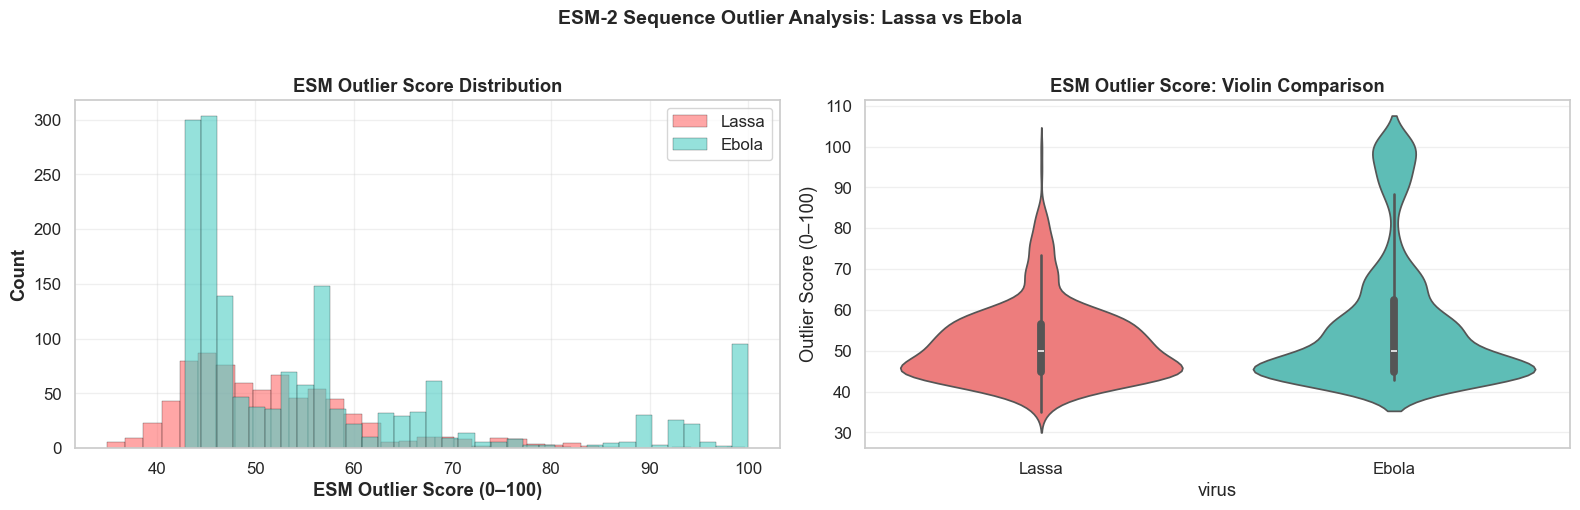

,virus,n_sequences,mean_outlier_score,std_outlier_score,n_high_outlier_gt80
0,Lassa,780,51.749569,9.404971,13
1,Ebola,1610,56.854988,16.605131,199


✅ Saved: outlier_score_comparison.csv


In [25]:
# ============================================================
# 5.2 — Outlier score distribution comparison
# ============================================================
if lassa_emb is not None and ebola_emb is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram
    ax = axes[0]
    ax.hist(lassa_outlier_score, bins=35, alpha=0.6, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.3)
    ax.hist(ebola_outlier_score, bins=35, alpha=0.6, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.3)
    ax.set_xlabel("ESM Outlier Score (0\u2013100)", fontweight="bold")
    ax.set_ylabel("Count", fontweight="bold")
    ax.set_title("ESM Outlier Score Distribution", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

    # Violin
    ax = axes[1]
    outlier_df = pd.DataFrame({
        "outlier_score": np.concatenate([lassa_outlier_score, ebola_outlier_score]),
        "virus": ["Lassa"] * len(lassa_outlier_score) + ["Ebola"] * len(ebola_outlier_score)
    })
    sns.violinplot(data=outlier_df, x="virus", y="outlier_score", ax=ax,
                   palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
    ax.set_title("ESM Outlier Score: Violin Comparison", fontweight="bold")
    ax.set_ylabel("Outlier Score (0\u2013100)")
    ax.grid(axis="y", alpha=0.3)

    plt.suptitle("ESM-2 Sequence Outlier Analysis: Lassa vs Ebola", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_path = FIG_DIR / "09_outlier_score_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"\u2705 Saved: {fig_path.name}")
    plt.show()

    # Save outlier summary
    outlier_summary = pd.DataFrame([
        {"virus": "Lassa", "n_sequences": len(lassa_outlier_score),
         "mean_outlier_score": lassa_outlier_score.mean(),
         "std_outlier_score": lassa_outlier_score.std(),
         "n_high_outlier_gt80": (lassa_outlier_score > 80).sum()},
        {"virus": "Ebola", "n_sequences": len(ebola_outlier_score),
         "mean_outlier_score": ebola_outlier_score.mean(),
         "std_outlier_score": ebola_outlier_score.std(),
         "n_high_outlier_gt80": (ebola_outlier_score > 80).sum()},
    ])
    display(outlier_summary)
    outlier_summary.to_csv(TBL_DIR / "outlier_score_comparison.csv", index=False)
    print("\u2705 Saved: outlier_score_comparison.csv")
else:
    print("Skipping outlier plots (no embeddings).")

---

## SECTION 6 — Side-by-Side Site Category Barcode Tracks

Visual comparison of where Critical / Conserved / Hotspot / Intermediate / MostlyGap sites fall along each reference protein.

✅ Saved: 10_site_category_barcode_comparison.png


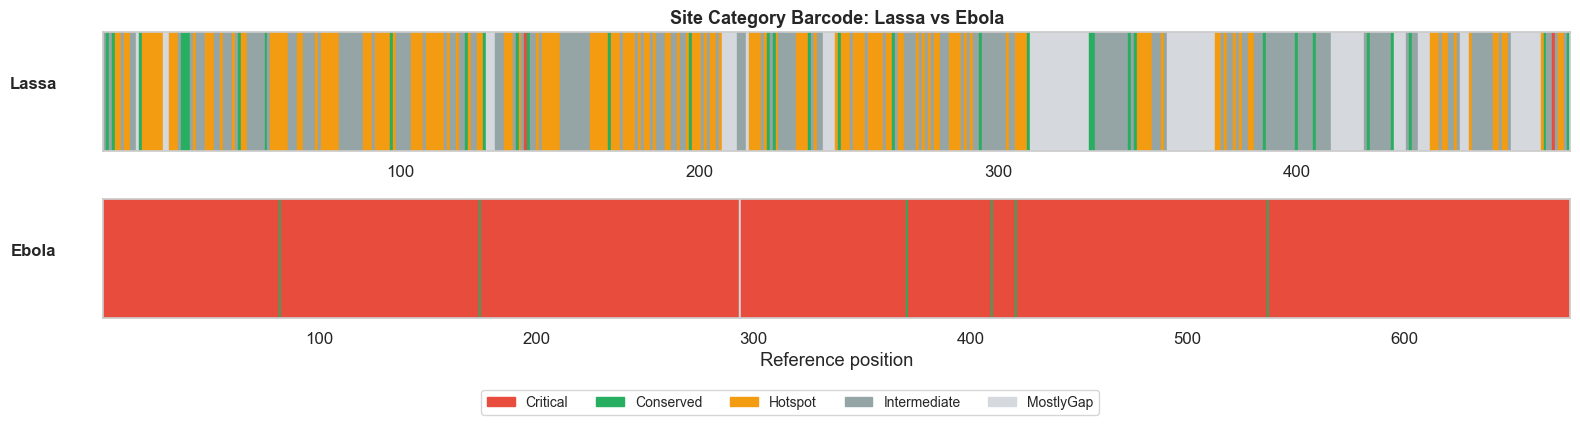

In [26]:
# ============================================================
# 6.1 — Side-by-side barcode (category stripe) plots
# ============================================================
barcode_colors = {
    "Critical": "#e74c3c",
    "Conserved": "#27ae60",
    "Hotspot": "#f39c12",
    "Intermediate": "#95a5a6",
    "MostlyGap": "#d5d8dc",
}

fig, axes = plt.subplots(2, 1, figsize=(16, 4), sharex=False)

for idx, (virus, site_df, ax) in enumerate([
    ("Lassa", lassa_site, axes[0]),
    ("Ebola", ebola_site, axes[1]),
]):
    for _, row in site_df.iterrows():
        c = barcode_colors.get(row["site_category"], "#d5d8dc")
        ax.axvspan(row["ref_pos"] - 0.5, row["ref_pos"] + 0.5, color=c)
    ax.set_xlim(0.5, site_df["ref_pos"].max() + 0.5)
    ax.set_yticks([])
    ax.set_ylabel(virus, fontweight="bold", fontsize=12, rotation=0, labelpad=50)
    ax.set_xlabel("Reference position" if idx == 1 else "")

axes[0].set_title("Site Category Barcode: Lassa vs Ebola", fontweight="bold", fontsize=13)

# Shared legend
handles = [mpatches.Patch(color=barcode_colors[c], label=c) for c in ALL_CATS]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
fig_path = FIG_DIR / "10_site_category_barcode_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

---

## SECTION 7 — Conservation / Entropy Curve Overlay (Normalized Position)

Since Lassa and Ebola reference proteins have different lengths, we normalize positions to 0\u20131 (fractional position) and overlay conservation and entropy curves.

This reveals which *regions* (N-terminal, middle, C-terminal) are more constrained in each virus.

✅ Saved: 11_normalized_conservation_entropy_overlay.png


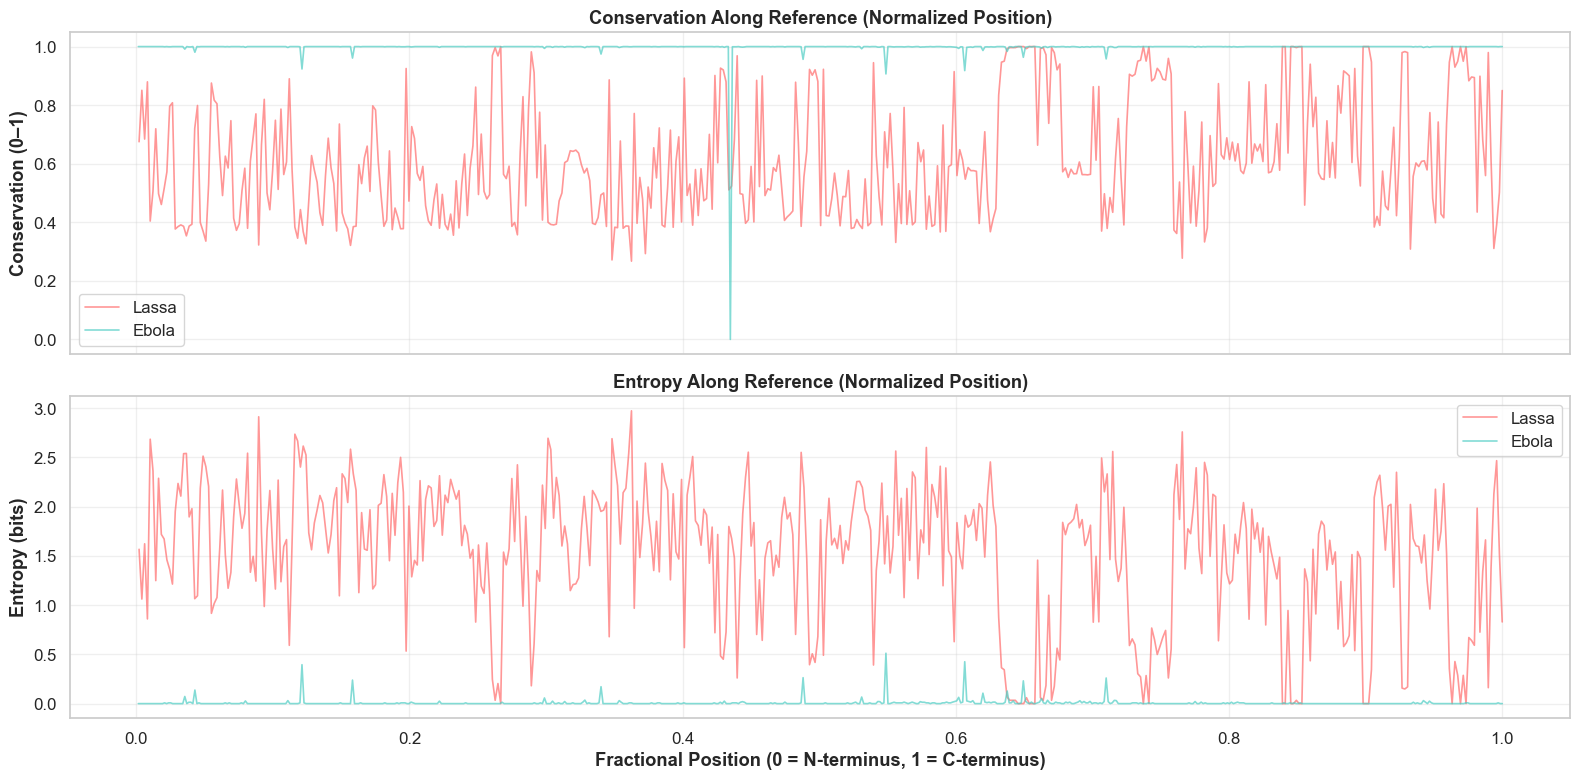

In [27]:
# ============================================================
# 7.1 — Normalized-position conservation & entropy overlay
# ============================================================
lassa_site["frac_pos"] = lassa_site["ref_pos"] / lassa_site["ref_pos"].max()
ebola_site["frac_pos"] = ebola_site["ref_pos"] / ebola_site["ref_pos"].max()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Conservation
ax = axes[0]
ax.plot(lassa_site["frac_pos"], lassa_site["conservation"], alpha=0.7, label="Lassa", color="#FF6B6B", linewidth=1.2)
ax.plot(ebola_site["frac_pos"], ebola_site["conservation"], alpha=0.7, label="Ebola", color="#4ECDC4", linewidth=1.2)
ax.set_ylabel("Conservation (0\u20131)", fontweight="bold")
ax.set_title("Conservation Along Reference (Normalized Position)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# Entropy
ax = axes[1]
ax.plot(lassa_site["frac_pos"], lassa_site["entropy"], alpha=0.7, label="Lassa", color="#FF6B6B", linewidth=1.2)
ax.plot(ebola_site["frac_pos"], ebola_site["entropy"], alpha=0.7, label="Ebola", color="#4ECDC4", linewidth=1.2)
ax.set_xlabel("Fractional Position (0 = N-terminus, 1 = C-terminus)", fontweight="bold")
ax.set_ylabel("Entropy (bits)", fontweight="bold")
ax.set_title("Entropy Along Reference (Normalized Position)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "11_normalized_conservation_entropy_overlay.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

---

## SECTION 8 — Sequence Length Comparison

How do the sequence length distributions compare? This gives biological context for why embeddings and conservation patterns differ.

✅ Saved: 12_sequence_length_comparison.png


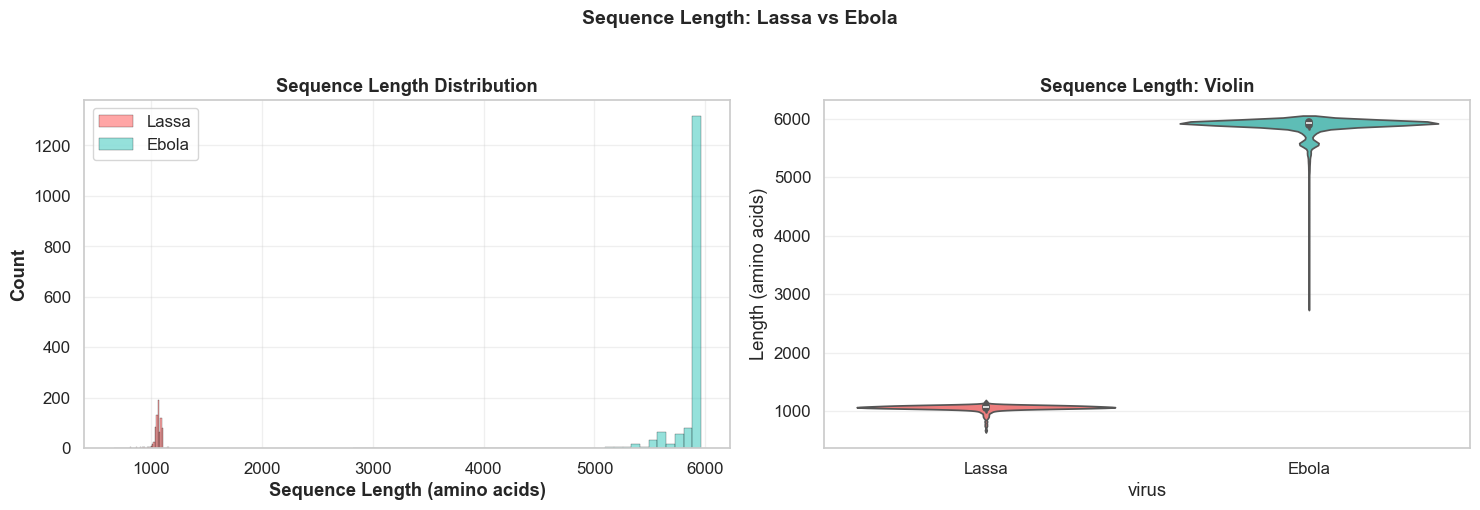


Lassa: 1057 ± 55 aa  (range: 664–1160)
Ebola: 5869 ± 203 aa  (range: 2820–5960)


In [28]:
# ============================================================
# 8.1 — Sequence length comparison
# ============================================================
if lassa_meta is not None and ebola_meta is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    ax = axes[0]
    if "length" in lassa_meta.columns and "length" in ebola_meta.columns:
        ax.hist(lassa_meta["length"], bins=40, alpha=0.6, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.3)
        ax.hist(ebola_meta["length"], bins=40, alpha=0.6, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.3)
        ax.set_xlabel("Sequence Length (amino acids)", fontweight="bold")
        ax.set_ylabel("Count", fontweight="bold")
        ax.set_title("Sequence Length Distribution", fontweight="bold")
        ax.legend()
        ax.grid(alpha=0.3)

        # Violin
        ax = axes[1]
        len_df = pd.concat([
            lassa_meta[["length"]].assign(virus="Lassa"),
            ebola_meta[["length"]].assign(virus="Ebola"),
        ])
        sns.violinplot(data=len_df, x="virus", y="length", ax=ax,
                       palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
        ax.set_title("Sequence Length: Violin", fontweight="bold")
        ax.set_ylabel("Length (amino acids)")
        ax.grid(axis="y", alpha=0.3)

        plt.suptitle("Sequence Length: Lassa vs Ebola", fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        fig_path = FIG_DIR / "12_sequence_length_comparison.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"\u2705 Saved: {fig_path.name}")
        plt.show()

        # Print stats
        print(f"\nLassa: {lassa_meta['length'].mean():.0f} \u00b1 {lassa_meta['length'].std():.0f} aa  (range: {lassa_meta['length'].min()}\u2013{lassa_meta['length'].max()})")
        print(f"Ebola: {ebola_meta['length'].mean():.0f} \u00b1 {ebola_meta['length'].std():.0f} aa  (range: {ebola_meta['length'].min()}\u2013{ebola_meta['length'].max()})")
    else:
        print("No 'length' column in metadata. Skipping.")
else:
    print("\u26a0\ufe0f  Metadata not loaded. Skipping sequence length comparison.")

---

## SECTION 9 — Combined Summary Dashboard

A single multi-panel figure summarizing the key comparisons for publication or reporting.

✅ Saved: 13_summary_dashboard.png


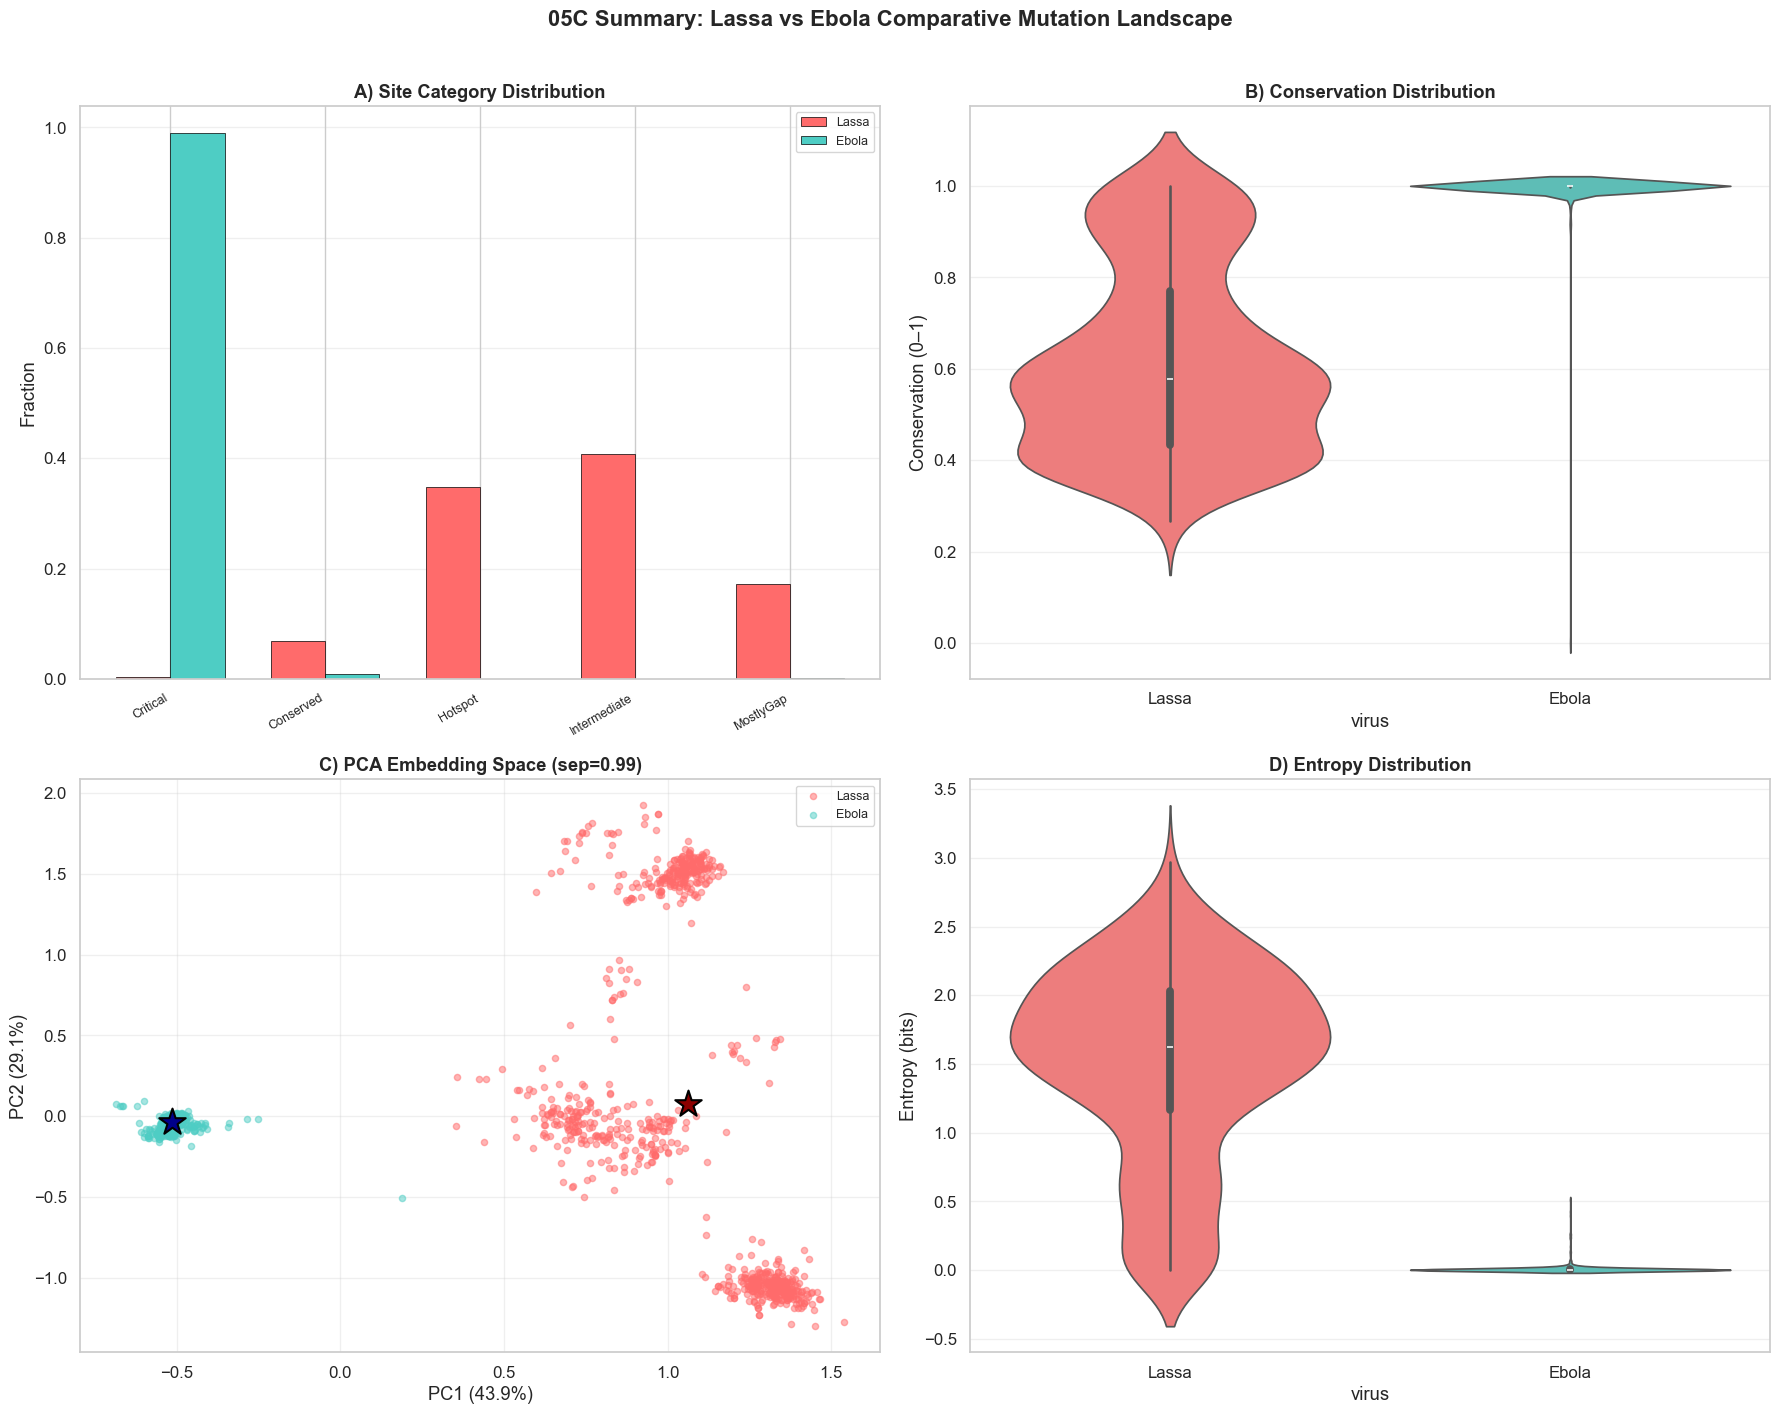

In [29]:
# ============================================================
# 9.1 — Summary dashboard (4-panel figure)
# ============================================================
fig = plt.figure(figsize=(18, 14))

# Panel A: Site category bar chart
ax1 = fig.add_subplot(2, 2, 1)
x = np.arange(len(ALL_CATS))
width = 0.35
lassa_vals = [pivot.loc[c, "Lassa"] for c in ALL_CATS]
ebola_vals = [pivot.loc[c, "Ebola"] for c in ALL_CATS]
ax1.bar(x - width/2, lassa_vals, width, label="Lassa", color="#FF6B6B", edgecolor="black", linewidth=0.5)
ax1.bar(x + width/2, ebola_vals, width, label="Ebola", color="#4ECDC4", edgecolor="black", linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(ALL_CATS, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("Fraction")
ax1.set_title("A) Site Category Distribution", fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# Panel B: Conservation violin
ax2 = fig.add_subplot(2, 2, 2)
sns.violinplot(data=combined_site, x="virus", y="conservation", ax=ax2,
               palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
ax2.set_title("B) Conservation Distribution", fontweight="bold")
ax2.set_ylabel("Conservation (0\u20131)")
ax2.grid(axis="y", alpha=0.3)

# Panel C: PCA (if available)
ax3 = fig.add_subplot(2, 2, 3)
if lassa_emb is not None and ebola_emb is not None:
    ax3.scatter(lassa_2d[:, 0], lassa_2d[:, 1], c="#FF6B6B", label="Lassa", alpha=0.5, s=20)
    ax3.scatter(ebola_2d[:, 0], ebola_2d[:, 1], c="#4ECDC4", label="Ebola", alpha=0.5, s=20)
    ax3.scatter(*lassa_cent, c="darkred", marker="*", s=400, edgecolor="black", linewidth=1.5, zorder=5)
    ax3.scatter(*ebola_cent, c="darkblue", marker="*", s=400, edgecolor="black", linewidth=1.5, zorder=5)
    ax3.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax3.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax3.set_title(f"C) PCA Embedding Space (sep={sep_ratio:.2f})", fontweight="bold")
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3)
else:
    ax3.text(0.5, 0.5, "Embeddings not available", ha="center", va="center", transform=ax3.transAxes)
    ax3.set_title("C) PCA Embedding Space", fontweight="bold")

# Panel D: Entropy violin
ax4 = fig.add_subplot(2, 2, 4)
sns.violinplot(data=combined_site, x="virus", y="entropy", ax=ax4,
               palette={"Lassa": "#FF6B6B", "Ebola": "#4ECDC4"}, inner="box")
ax4.set_title("D) Entropy Distribution", fontweight="bold")
ax4.set_ylabel("Entropy (bits)")
ax4.grid(axis="y", alpha=0.3)

plt.suptitle("05C Summary: Lassa vs Ebola Comparative Mutation Landscape",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "13_summary_dashboard.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\u2705 Saved: {fig_path.name}")
plt.show()

---

## SECTION 10 — Final Summary & Biological Interpretation

In [30]:
# ============================================================
# 10 — FINAL SUMMARY REPORT
# ============================================================
print("\n" + "=" * 70)
print("\u2705 05C COMPARATIVE ANALYSIS COMPLETE")
print("=" * 70)

print(f"\n\U0001f4ca DATASET SUMMARY:")
print(f"   Lassa: {lassa_site.shape[0]} reference positions, {len(lassa_sub_norm):,} substitutions scored")
print(f"   Ebola: {ebola_site.shape[0]} reference positions, {len(ebola_mut_norm):,} substitutions scored")
if lassa_emb is not None:
    print(f"   Lassa embeddings: {lassa_emb.shape[0]} sequences \u00d7 {lassa_emb.shape[1]}D")
if ebola_emb is not None:
    print(f"   Ebola embeddings: {ebola_emb.shape[0]} sequences \u00d7 {ebola_emb.shape[1]}D")

print(f"\n\U0001f9ec SITE CATEGORY COMPARISON:")
print(f"   Lassa:  {pivot.loc['Critical', 'Lassa']:.1%} Critical | {pivot.loc['Hotspot', 'Lassa']:.1%} Hotspot | {pivot.loc['Conserved', 'Lassa']:.1%} Conserved")
print(f"   Ebola:  {pivot.loc['Critical', 'Ebola']:.1%} Critical | {pivot.loc['Hotspot', 'Ebola']:.1%} Hotspot | {pivot.loc['Conserved', 'Ebola']:.1%} Conserved")

more_constrained = "Ebola" if ebola_critical_frac > lassa_critical_frac else "Lassa"
more_variable = "Lassa" if lassa_hotspot_frac > ebola_hotspot_frac else "Ebola"
print(f"   \u27a1\ufe0f {more_constrained} is MORE constrained (higher Critical fraction)")
print(f"   \u27a1\ufe0f {more_variable} is MORE variable (higher Hotspot fraction)")

print(f"\n\U0001f4c8 CONSERVATION & ENTROPY:")
l_cons = lassa_site['conservation'].mean()
e_cons = ebola_site['conservation'].mean()
l_ent = lassa_site['entropy'].mean()
e_ent = ebola_site['entropy'].mean()
print(f"   Mean conservation: Lassa={l_cons:.3f}, Ebola={e_cons:.3f}")
print(f"   Mean entropy:      Lassa={l_ent:.3f}, Ebola={e_ent:.3f}")

if lassa_emb is not None and ebola_emb is not None:
    print(f"\n\U0001f50d EMBEDDING SPACE:")
    print(f"   Centroid Euclidean distance: {euclid_dist:.4f}")
    print(f"   Centroid cosine distance:    {cos_dist:.6f}")
    print(f"   Separation ratio:            {sep_ratio:.4f}")
    sep_label = "EXCELLENT" if sep_ratio > 2 else "GOOD" if sep_ratio > 1 else "POOR"
    print(f"   Status: {sep_label}")

print(f"\n\U0001f4be SAVED FILES:")
print(f"   Tables:  {TBL_DIR.resolve()}")
for p in sorted(TBL_DIR.glob("*.csv")):
    print(f"     \u2713 {p.name}")
print(f"   Figures: {FIG_DIR.resolve()}")
for p in sorted(FIG_DIR.glob("*.png")):
    print(f"     \u2713 {p.name}")

print(f"\n" + "=" * 70)
print("\U0001f680 READY FOR STEP 06: Predictive Model & Interactive Mutation Explainer")
print("=" * 70)


✅ 05C COMPARATIVE ANALYSIS COMPLETE

📊 DATASET SUMMARY:
   Lassa: 491 reference positions, 9,820 substitutions scored
   Ebola: 676 reference positions, 12,844 substitutions scored
   Lassa embeddings: 780 sequences × 1280D
   Ebola embeddings: 1610 sequences × 1280D

🧬 SITE CATEGORY COMPARISON:
   Lassa:  0.4% Critical | 34.8% Hotspot | 6.9% Conserved
   Ebola:  99.0% Critical | 0.0% Hotspot | 0.9% Conserved
   ➡️ Ebola is MORE constrained (higher Critical fraction)
   ➡️ Lassa is MORE variable (higher Hotspot fraction)

📈 CONSERVATION & ENTROPY:
   Mean conservation: Lassa=0.616, Ebola=0.997
   Mean entropy:      Lassa=1.508, Ebola=0.008

🔍 EMBEDDING SPACE:
   Centroid Euclidean distance: 1.5857
   Centroid cosine distance:    0.013205
   Separation ratio:            0.9940
   Status: POOR

💾 SAVED FILES:
   Tables:  /Users/user/data/results/comparative_05c/tables
     ✓ conservation_entropy_summary_stats.csv
     ✓ embedding_comparison_stats.csv
     ✓ observed_substitution_compari

## Biological Interpretation

### Key Findings from 05C Comparative Analysis

1. **Constraint Profiles**
   - The fraction of **Critical** (extremely conserved) sites reveals which virus protein is under stronger purifying selection.
   - A higher Critical fraction suggests the protein has more functionally essential residues that cannot tolerate substitution.

2. **Hotspot Patterns**
   - Hotspot sites indicate regions of high amino acid diversity / rapid evolution.
   - These may correspond to immune-evasion domains, host-adaptation regions, or structurally flexible loops.

3. **Conservation vs Entropy**
   - Higher mean conservation across all positions indicates a more constrained protein overall.
   - Entropy differences may reflect different evolutionary pressures or dataset composition.

4. **ESM-2 Embedding Separation**
   - Clear separation in embedding space confirms the two viruses produce **distinct protein structures/functions** as captured by ESM-2.
   - The separation ratio quantifies how well the two virus families are distinguished.

5. **Implications for Drug/Vaccine Targets**
   - **Critical sites** in both viruses are prime candidates for broad-spectrum drug targets.
   - **Hotspot sites** unique to one virus may explain differential pathogenicity or immune escape.

---

### Next Steps

- **Step 06**: Build a predictive model that takes a user\'s reference + query sequence, auto-embeds with ESM-2, scores mutations, and provides end-to-end explanations:
  - *Where is the mutation?* (reference position)
  - *What site category?* (Critical / Hotspot / Conserved)
  - *How risky?* (impact score + BLOSUM62)
  - *How does it compare to the other virus?* (cross-virus context from 05C tables)